# Analisis filtro ambiente (2do orden, 6 canales)

Carga cada barrido hecho **con el filtro ambiente conectado**, lo grafica, y
calcula la f_c medida, comparandola contra la f_c teorica **con los 50 Ohm
del generador y del analizador incluidos** (ver seccion de canales). Las f_c
de `CLAUDE.md` son del filtro sin carga y no corresponden a esta medicion.

El filtro tiene una perdida de insercion fija (~2.2 dB en el canal de 15 Ohm,
~6 dB en el de 51 Ohm, ~12 dB en el de 150 Ohm): las dos R serie del filtro
forman un divisor de tension con los 50 + 50 Ohm. Esa perdida esta en toda
la banda, incluso muy por debajo del corte, asi que la f_c se mide como el
cruce de -3 dB respecto del nivel de banda pasante del propio barrido (no
respecto de 0 dB).

Por cada canal en `canales`:
1. Carga el barrido y grafica la amplitud del pico medida cruda.
2. Calcula f_c medida (cruce de -3 dB respecto a la banda pasante propia del
   barrido) y la compara contra la f_c teorica con 50 Ohm.

In [100]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


def cargar_barrido(carpeta, exclude_bins=5):
    archivos = sorted(carpeta.glob("sweep_f_test_*.csv"))
    filas = []
    for archivo in archivos:
        m = re.search(r"sweep_f_test_([\d.]+)kHz", archivo.name)
        f_test = float(m.group(1)) * 1e3

        df = pd.read_csv(archivo)
        freq = df["Frequency"].to_numpy()
        amp = df["Amplitude"].to_numpy()

        # np.argmax(amp) a veces agarra el borde de la ventana (f_start) en
        # vez del tono inyectado: cuando f_test es chico, el span minimo del
        # SA fuerza f_start cerca de 1 Hz, y ahi hay una fuga/artefacto que
        # puede ser mas fuerte que el tono real. find_peaks exige un maximo
        # local (vecino de los dos lados), asi que no cuenta el borde.
        picos, _ = find_peaks(amp)
        i = picos[np.argmax(amp[picos])] if len(picos) > 0 else int(np.argmax(amp))

        # piso de ruido: mediana de la traza lejos del pico (si no, el tono
        # contamina la mediana), para poder calcular el SNR de cada punto
        mask = np.ones(len(amp), dtype=bool)
        lo, hi = max(0, i - exclude_bins), min(len(amp), i + exclude_bins + 1)
        mask[lo:hi] = False
        noise_floor = np.median(amp[mask])

        filas.append({
            "f_test": f_test,
            "peak_freq": freq[i],
            "peak_amp": amp[i],
            "noise_floor_dbm": noise_floor,
            "snr_db": amp[i] - noise_floor,
        })

    return pd.DataFrame(filas).sort_values("f_test").reset_index(drop=True)

## Canales del filtro ambiente

Filtro RC pasabajos de 2do orden (R - C a masa - R - C a masa), 6
configuraciones R-C, una por canal. Las f_c de `CLAUDE.md` son del filtro
solo, sin nada conectado (fuente ideal, Rs = 0, y salida en vacio, RL = inf).

En la medicion no es asi: el generador tiene 50 Ohm de salida y el
analizador 50 Ohm de entrada. Esas dos resistencias forman parte del
circuito, cambian la f_c y agregan una perdida en continua (divisor
resistivo entre las dos R del filtro y los 50 + 50 Ohm).

```
Vg -- Rs=50 -- R --+-- R --+-- RL=50 (analizador)
                   C       C
                   |       |
                  GND     GND
```

Resolviendo el circuito, con s = j 2 pi f y tau = RC:

$$\frac{V_{out}}{V_g} = \frac{1}{A + B/R_L + R_s\,(C' + D/R_L)}$$

$$A = 1 + 3s\tau + (s\tau)^2, \quad B = R(2 + s\tau), \quad C' = sC(2 + s\tau), \quad D = 1 + s\tau$$

La celda de abajo calcula f_c (-3 dB respecto de la continua) para cada
configuracion, sin carga y con 50 Ohm, y la perdida en continua respecto
del loopback sin filtro (que es lo que se ve como offset en la curva
normalizada: 20 log10[(Rs + RL) / (Rs + RL + 2R)]).

In [101]:
from scipy.optimize import brentq

R_GEN = 50      # impedancia de salida del generador [Ohm]
R_SA = 50       # impedancia de entrada del analizador [Ohm]


def transferencia(f, R, C, Rs=0, RL=np.inf):
    # Vout/Vg para: generador (Rs) -> R -> C a masa -> R -> C a masa -> carga (RL)
    s = 2j * np.pi * f
    t = R * C
    A = 1 + 3 * s * t + (s * t) ** 2
    B = R * (2 + s * t)
    Cc = s * C * (2 + s * t)
    D = 1 + s * t
    return 1 / (A + B / RL + Rs * (Cc + D / RL))


def fc_teorica(R, C, Rs=0, RL=np.inf):
    # frecuencia donde |H| cae 3 dB respecto de su valor en continua
    h0 = abs(transferencia(1e-3, R, C, Rs, RL))
    g = lambda logf: abs(transferencia(10 ** logf, R, C, Rs, RL)) / h0 - 1 / np.sqrt(2)
    return 10 ** brentq(g, 0, 7)


configs = [(150, 2.2e-6), (150, 1e-6), (51, 2.2e-6), (51, 1e-6), (15, 2.2e-6), (15, 1e-6)]

filas = []
for R, C in configs:
    # la perdida en continua se mide respecto del loopback (sin filtro), que ya
    # tiene el divisor R_GEN / R_SA
    loopback = R_SA / (R_GEN + R_SA)
    perdida = 20 * np.log10(abs(transferencia(1e-3, R, C, R_GEN, R_SA)) / loopback)
    filas.append({
        "R [Ohm]": R,
        "C [uF]": C * 1e6,
        "fc sin carga [Hz]": round(fc_teorica(R, C)),
        "fc con 50 Ohm [Hz]": round(fc_teorica(R, C, R_GEN, R_SA)),
        "perdida en continua [dB]": round(perdida, 2),
    })

tabla_fc = pd.DataFrame(filas)
tabla_fc

,R [Ohm],C [uF],fc sin carga [Hz],fc con 50 Ohm [Hz],perdida en continua [dB]
0,150,2.2,180,608,-12.04
1,150,1.0,397,1338,-12.04
2,51,2.2,531,975,-6.11
3,51,1.0,1168,2144,-6.11
4,15,2.2,1805,1260,-2.28
5,15,1.0,3971,2772,-2.28


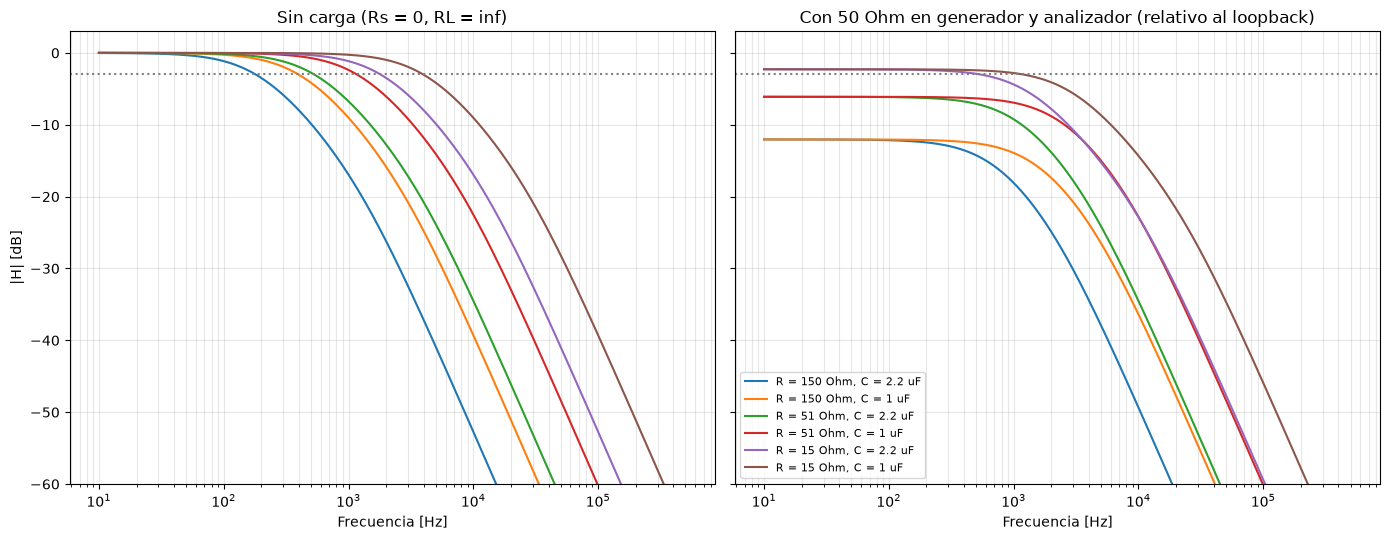

In [102]:
f = np.logspace(1, 5.7, 500)

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
for R, C in configs:
    etiqueta = f"R = {R} Ohm, C = {C * 1e6:g} uF"
    h_sin = abs(transferencia(f, R, C))
    h_con = abs(transferencia(f, R, C, R_GEN, R_SA)) / (R_SA / (R_GEN + R_SA))
    axs[0].plot(f, 20 * np.log10(h_sin), label=etiqueta)
    axs[1].plot(f, 20 * np.log10(h_con), label=etiqueta)

axs[0].set_title("Sin carga (Rs = 0, RL = inf)")
axs[1].set_title("Con 50 Ohm en generador y analizador (relativo al loopback)")
axs[0].set_ylabel("|H| [dB]")
for ax in axs:
    ax.axhline(-3, color="gray", linestyle=":")
    ax.set_xscale("log")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylim(-60, 3)
    ax.grid(True, which="both", alpha=0.3)
axs[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [103]:
# R [Ohm] y C [F] del canal al que estaba conectado cada cable (no se puede
# inferir del nombre de la carpeta). La f_c teorica se calcula con 50 Ohm.
canales = {
    "cable2": {"carpeta": Path("../barridos/5/barrido_filtroamb_cable2"), "R": 15, "C": 2.2e-6},
    "cable24": {"carpeta": Path("../barridos/5/barrido_filtroamb_cable24"), "R": 51, "C": 2.2e-6},
    "cable23": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable23"), "R": 51, "C": 2.2e-6},
    "cable9": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable9"), "R": 150, "C": 1e-6},
        "cable3": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable3"), "R": 15, "C": 1e-6},
            "cable13": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable13"), "R": 51, "C": 1e-6},
                "cable18": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable18"), "R": 150, "C": 2.2e-6},             
                    "cable14": {"carpeta": Path("../barridos/6/barrido_filtroamb_cable14"), "R": 51, "C": 1e-6},



}

for cfg in canales.values():
    cfg["f_c_teorica_hz"] = fc_teorica(cfg["R"], cfg["C"], R_GEN, R_SA)


## Funcion de analisis por canal

Para cada canal: carga el barrido con filtro, lo grafica crudo, y calcula
f_c medida usando como referencia la propia banda pasante del barrido
(promedio de amplitud en `f_test < f_c_teorica/10`, donde el filtro todavia
casi no atenua -- ver nota de arriba sobre por que esto da mejor que
normalizar contra un barrido sin filtro).

f_c medida es donde la atenuacion respecto a esa banda pasante cruza 3 dB
(mitad de potencia), interpolando en escala log de frecuencia (asume que la
atenuacion crece mas o menos monotona cerca del corte -- aproximado, ver
aviso si no da un numero razonable).

In [104]:
def analizar_canal(nombre, carpeta, f_c_teorica_hz, exclude_bins=5):
    resultados = cargar_barrido(carpeta, exclude_bins=exclude_bins)
    if len(resultados) == 0:
        raise FileNotFoundError(f"No hay archivos sweep_f_test_*.csv en {carpeta}")

    log_f = np.log10(resultados["f_test"])

    en_banda_pasante = resultados["f_test"] < f_c_teorica_hz / 10
    amp_banda_pasante = resultados.loc[en_banda_pasante, "peak_amp"].mean()
    atenuacion_db = amp_banda_pasante - resultados["peak_amp"]
    f_c_medida_hz = 10 ** np.interp(3, atenuacion_db, log_f)

    plt.figure(figsize=(12, 5.5))
    plt.plot(resultados["f_test"], resultados["peak_amp"], "o-", ms=3)
    plt.axvline(f_c_teorica_hz, color="tab:red", linestyle="--", label=f"f_c teorica (con 50 Ohm) = {f_c_teorica_hz:.0f} Hz")
    plt.axvline(f_c_medida_hz, color="tab:green", linestyle="--", label=f"f_c medida = {f_c_medida_hz:.0f} Hz")
    plt.xscale("log")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Amplitud del pico [dBm]")
    plt.title(f"{nombre} - barrido con filtro (crudo, sin normalizar)")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

    print(f"{nombre}: f_c medida = {f_c_medida_hz:.1f} Hz (teorica con 50 Ohm: {f_c_teorica_hz:.0f} Hz, "
          f"diferencia: {(f_c_medida_hz / f_c_teorica_hz - 1) * 100:+.1f}%)")

    return {
        "canal": nombre,
        "n_puntos": len(resultados),
        "f_c_teorica_hz": f_c_teorica_hz,
        "f_c_medida_hz": f_c_medida_hz,
    }, resultados

## Resultados por canal

Corre `analizar_canal` para cada canal de `canales`.


cable2


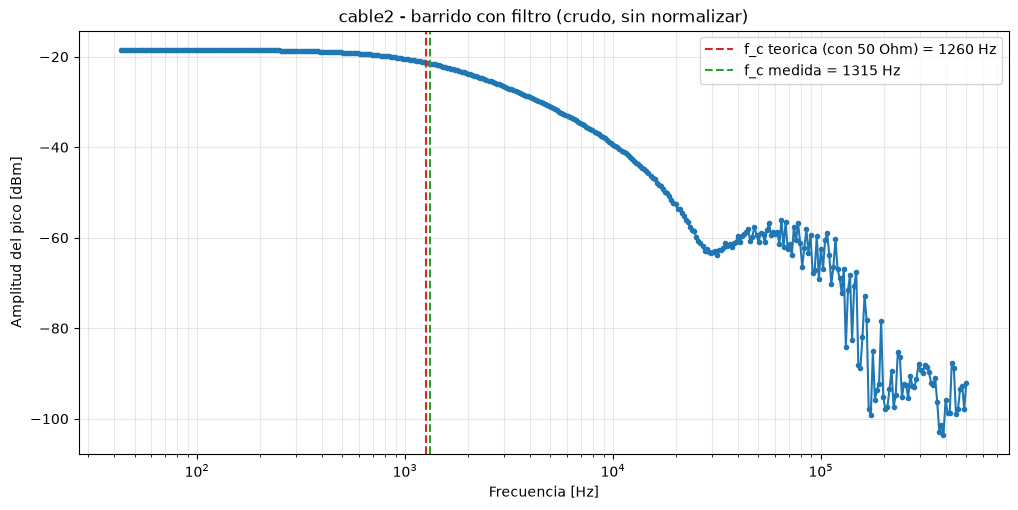

cable2: f_c medida = 1314.9 Hz (teorica con 50 Ohm: 1260 Hz, diferencia: +4.3%)

cable24


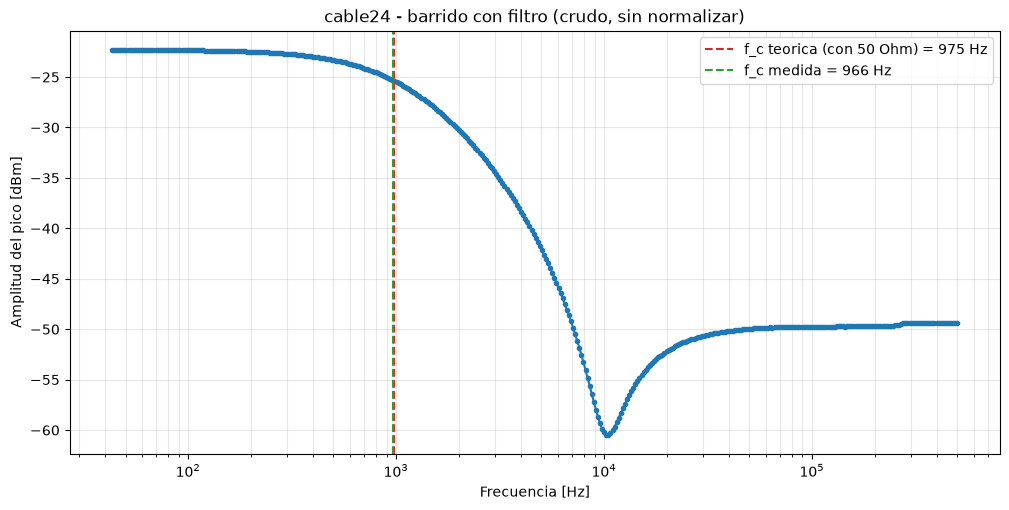

cable24: f_c medida = 966.5 Hz (teorica con 50 Ohm: 975 Hz, diferencia: -0.8%)

cable23


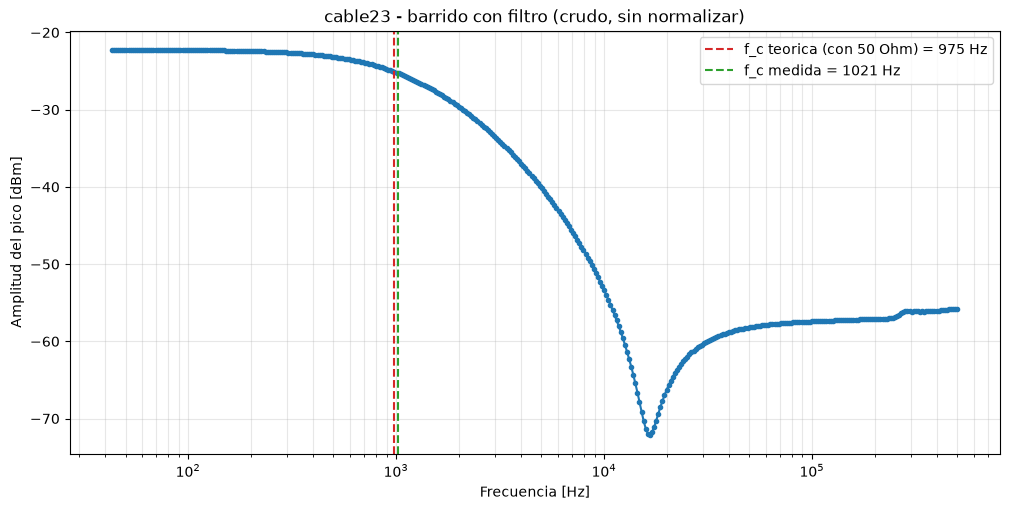

cable23: f_c medida = 1020.5 Hz (teorica con 50 Ohm: 975 Hz, diferencia: +4.7%)

cable9


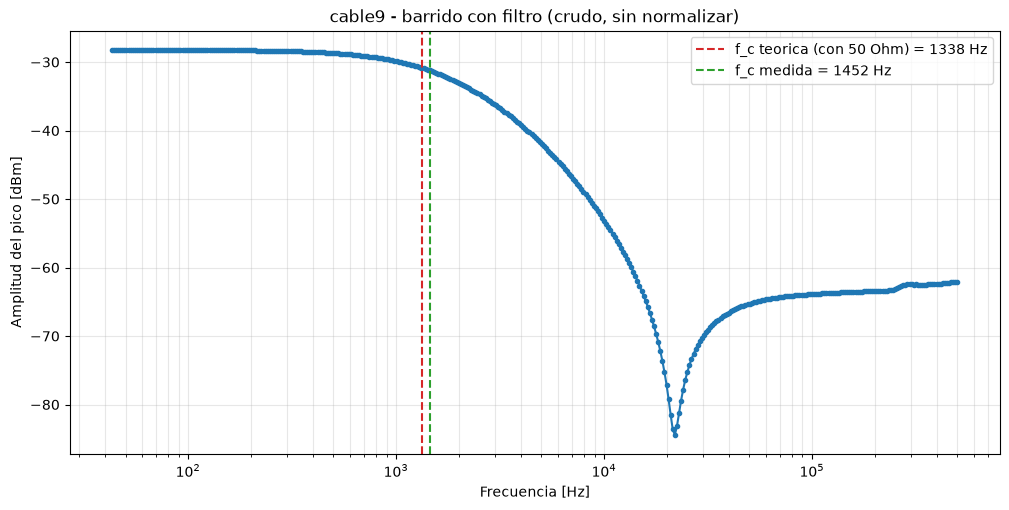

cable9: f_c medida = 1452.4 Hz (teorica con 50 Ohm: 1338 Hz, diferencia: +8.6%)

cable3


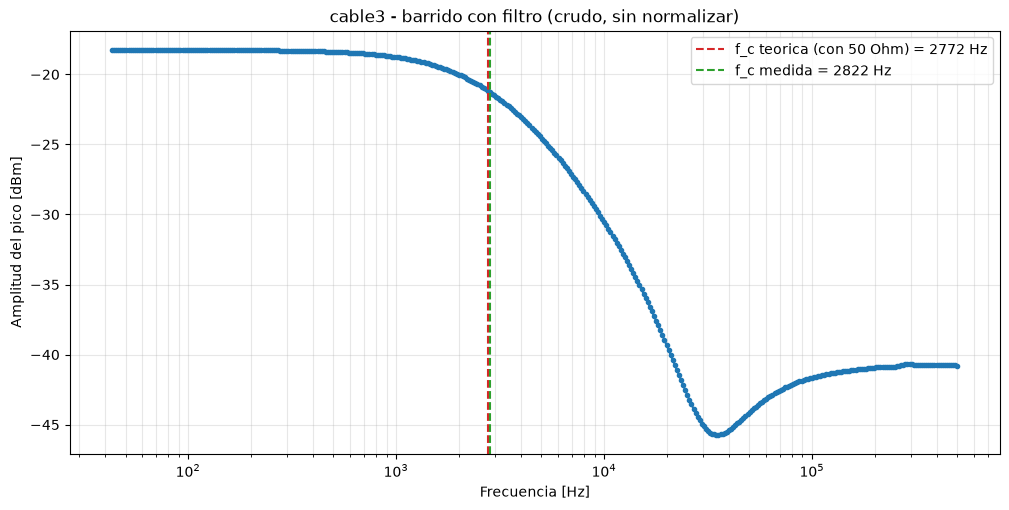

cable3: f_c medida = 2821.6 Hz (teorica con 50 Ohm: 2772 Hz, diferencia: +1.8%)

cable13


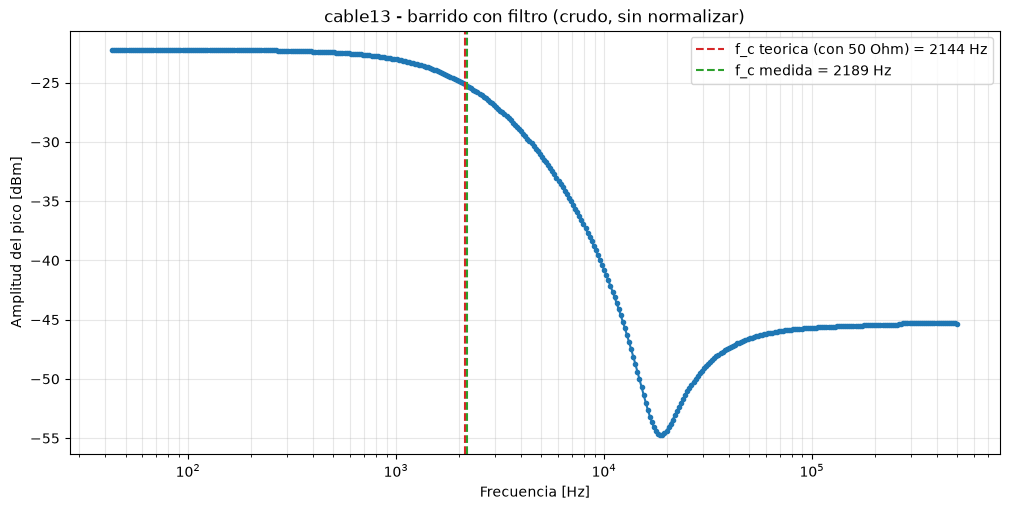

cable13: f_c medida = 2188.8 Hz (teorica con 50 Ohm: 2144 Hz, diferencia: +2.1%)

cable18


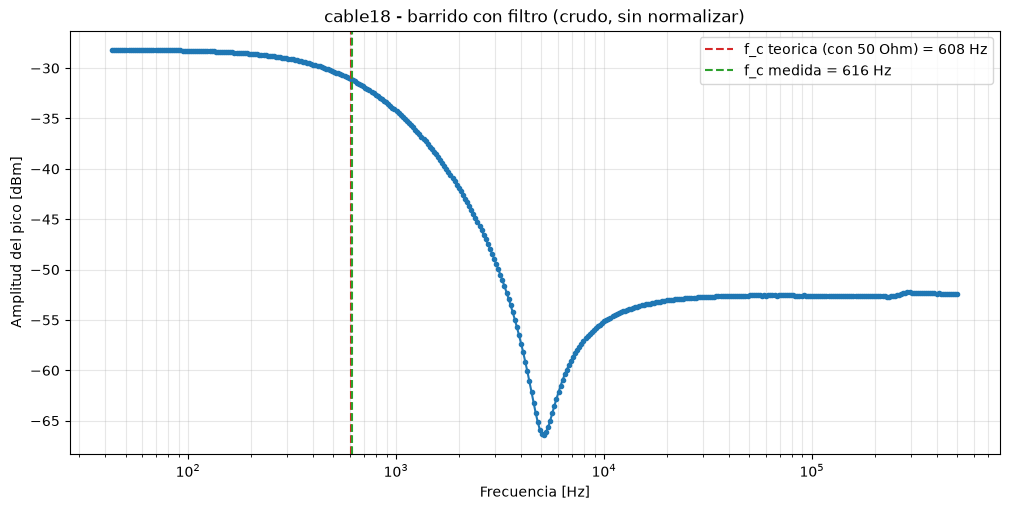

cable18: f_c medida = 616.3 Hz (teorica con 50 Ohm: 608 Hz, diferencia: +1.4%)

cable14


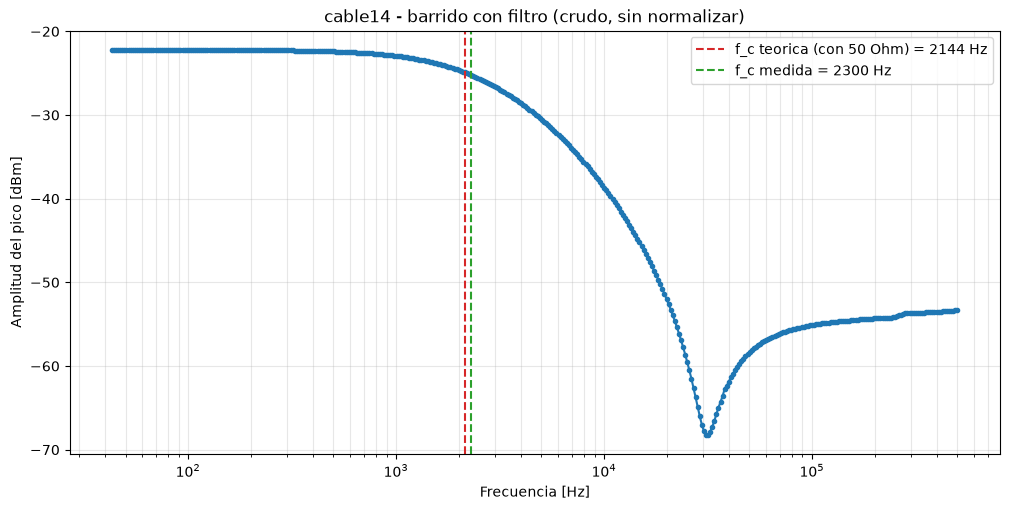

cable14: f_c medida = 2300.2 Hz (teorica con 50 Ohm: 2144 Hz, diferencia: +7.3%)


In [105]:
resumen = []
resultados_por_canal = {}

for nombre, cfg in canales.items():
    print(f"\n{'=' * 70}\n{nombre}\n{'=' * 70}")
    metrica, resultados_canal = analizar_canal(nombre, cfg["carpeta"], cfg["f_c_teorica_hz"])
    resumen.append(metrica)
    resultados_por_canal[nombre] = resultados_canal

## Comparacion normalizando

El metodo de arriba (banda pasante propia) es el que se usa para reportar
f_c. Esta seccion repite el calculo normalizando contra la calibracion sin
filtro `cable19` (dia 5, misma sesion que se midieron los canales del
filtro), para corregir el ripple de la cadena generador+cables+analizador
en funcion de la frecuencia.

La perdida de insercion fija del divisor R_ta/50 Ohm aparece como un offset
mas o menos constante en la banda pasante de la curva normalizada. Por eso
f_c se toma donde la curva cae **3 dB por debajo de ese offset** (no 3 dB
por debajo de 0 dB): asi la perdida fija no se suma a la caida del RC.

In [106]:
resultados_calibracion_cable19 = cargar_barrido(Path("../barridos/5/barrido_automatico_cable19"))

calibraciones = {
    "cable19": resultados_calibracion_cable19,
}

for nombre_cal, cal in calibraciones.items():
    print(f"{nombre_cal}: {len(cal)} puntos, {cal['f_test'].min():.3g} a {cal['f_test'].max():.3g} Hz, "
          f"ripple = {cal['peak_amp'].max() - cal['peak_amp'].min():.3f} dB pico a pico")

cable19: 407 puntos, 43 a 5e+05 Hz, ripple = 0.453 dB pico a pico


In [107]:
def analizar_canal_normalizado(nombre, carpeta, f_c_teorica_hz, resultados_calibracion, nombre_calibracion, exclude_bins=5):
    resultados = cargar_barrido(carpeta, exclude_bins=exclude_bins)
    if len(resultados) == 0:
        raise FileNotFoundError(f"No hay archivos sweep_f_test_*.csv en {carpeta}")

    log_f_calibracion = np.log10(resultados_calibracion["f_test"])
    log_f = np.log10(resultados["f_test"])
    amp_calibracion_interp = np.interp(log_f, log_f_calibracion, resultados_calibracion["peak_amp"])

    # 0 dB = igual que sin filtro (loopback), negativo = atenuado por el filtro
    peak_amp_norm_db = resultados["peak_amp"] - amp_calibracion_interp
    atenuacion_db_norm = -peak_amp_norm_db

    # offset "en continua": promedio de la atenuacion normalizada muy por
    # debajo del corte (f_c_teorica/10), donde el filtro todavia no deberia
    # atenuar nada -- por el divisor con los 50 Ohm del generador y del
    # analizador, esto deberia salir cerca de 20*log10((100 + 2R)/100) y no 0
    en_banda_pasante = resultados["f_test"] < f_c_teorica_hz / 10
    offset_continua_db = atenuacion_db_norm[en_banda_pasante].mean() if en_banda_pasante.sum() > 0 else np.nan

    # f_c = donde la atenuacion cae 3 dB POR DEBAJO DEL OFFSET (no de 0 dB):
    # la perdida de insercion fija no es parte de la caida del RC, asi que
    # la referencia tiene que ser el nivel de banda pasante del propio filtro
    f_c_medida_hz = 10 ** np.interp(offset_continua_db + 3, atenuacion_db_norm, log_f)

    plt.figure(figsize=(12, 5.5))
    plt.plot(resultados["f_test"], peak_amp_norm_db, "o-", ms=3, color="tab:purple")
    plt.axhline(-offset_continua_db, color="tab:orange", linestyle=":",
                label=f"offset en banda pasante = {-offset_continua_db:.2f} dB")
    plt.axhline(-offset_continua_db - 3, color="gray", linestyle=":",
                label=f"offset - 3 dB = {-offset_continua_db - 3:.2f} dB (mitad de potencia)")
    plt.axvline(f_c_teorica_hz, color="tab:red", linestyle="--", label=f"f_c teorica (con 50 Ohm) = {f_c_teorica_hz:.0f} Hz")
    plt.axvline(f_c_medida_hz, color="tab:green", linestyle="--", label=f"f_c medida (norm) = {f_c_medida_hz:.0f} Hz")
    plt.xscale("log")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel(f"Amplitud normalizada [dB] (relativa a {nombre_calibracion})")
    plt.title(f"{nombre} - normalizado con {nombre_calibracion}")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)
    plt.show()

    print(f"{nombre} (normalizado con {nombre_calibracion}): offset en banda pasante = {offset_continua_db:.2f} dB, "
          f"f_c medida = {f_c_medida_hz:.1f} Hz (teorica con 50 Ohm: {f_c_teorica_hz:.0f} Hz, "
          f"diferencia: {(f_c_medida_hz / f_c_teorica_hz - 1) * 100:+.1f}%)")

    return {
        "canal": nombre,
        "calibracion": nombre_calibracion,
        "offset_banda_pasante_db": offset_continua_db,
        "f_c_teorica_hz": f_c_teorica_hz,
        "f_c_medida_norm_hz": f_c_medida_hz,
    }


----------------------------------------------------------------------
cable2 normalizado con cable19
----------------------------------------------------------------------


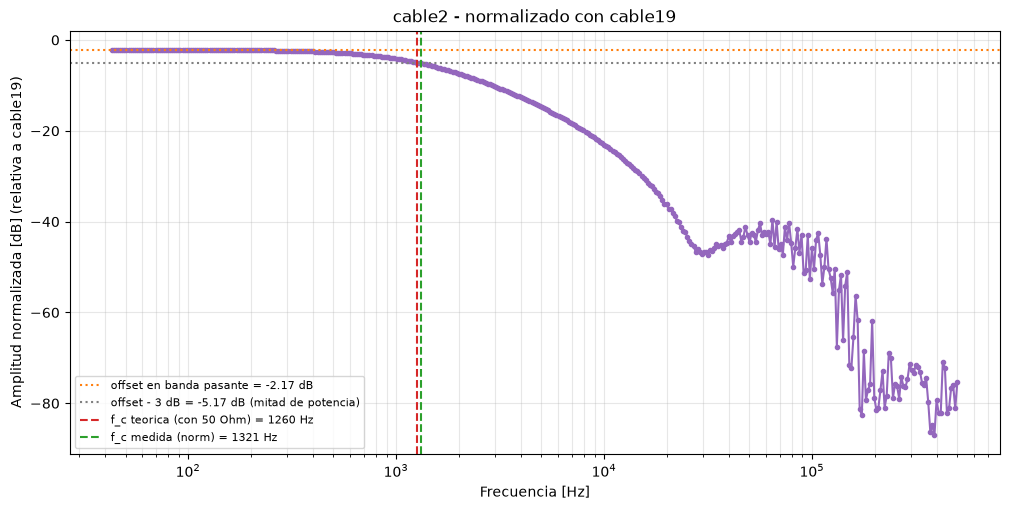

cable2 (normalizado con cable19): offset en banda pasante = 2.17 dB, f_c medida = 1320.9 Hz (teorica con 50 Ohm: 1260 Hz, diferencia: +4.8%)
offset teorico (divisor con 50 Ohm) = 2.28 dB

----------------------------------------------------------------------
cable24 normalizado con cable19
----------------------------------------------------------------------


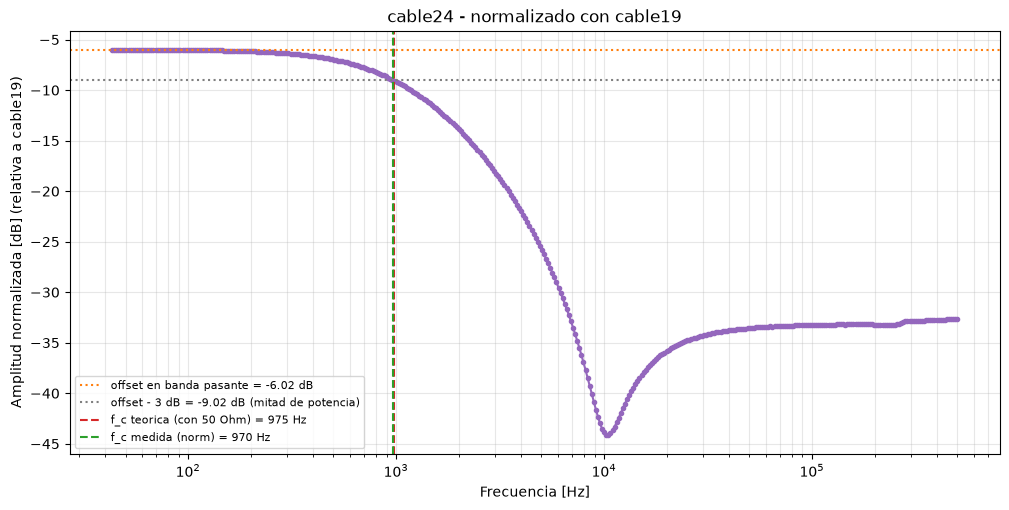

cable24 (normalizado con cable19): offset en banda pasante = 6.02 dB, f_c medida = 970.2 Hz (teorica con 50 Ohm: 975 Hz, diferencia: -0.4%)
offset teorico (divisor con 50 Ohm) = 6.11 dB

----------------------------------------------------------------------
cable23 normalizado con cable19
----------------------------------------------------------------------


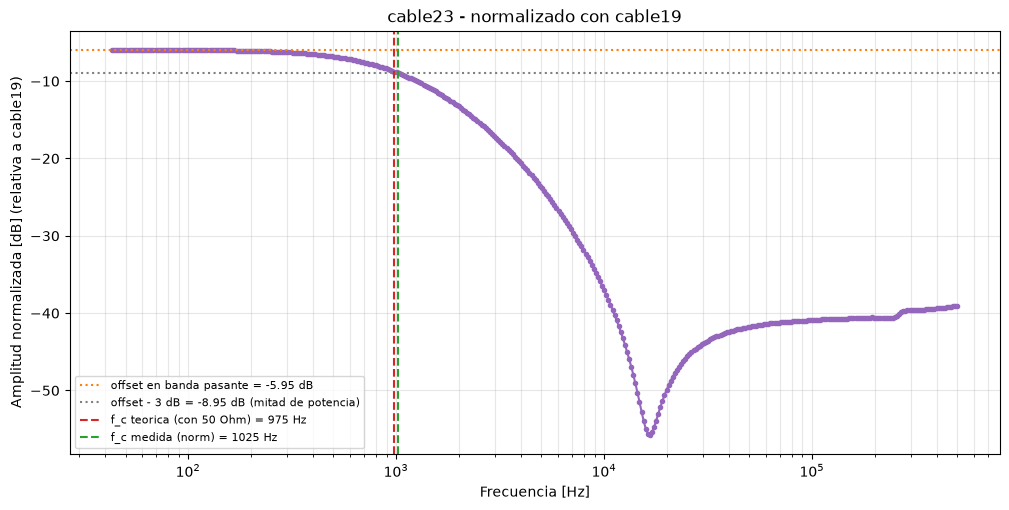

cable23 (normalizado con cable19): offset en banda pasante = 5.95 dB, f_c medida = 1024.7 Hz (teorica con 50 Ohm: 975 Hz, diferencia: +5.1%)
offset teorico (divisor con 50 Ohm) = 6.11 dB

----------------------------------------------------------------------
cable9 normalizado con cable19
----------------------------------------------------------------------


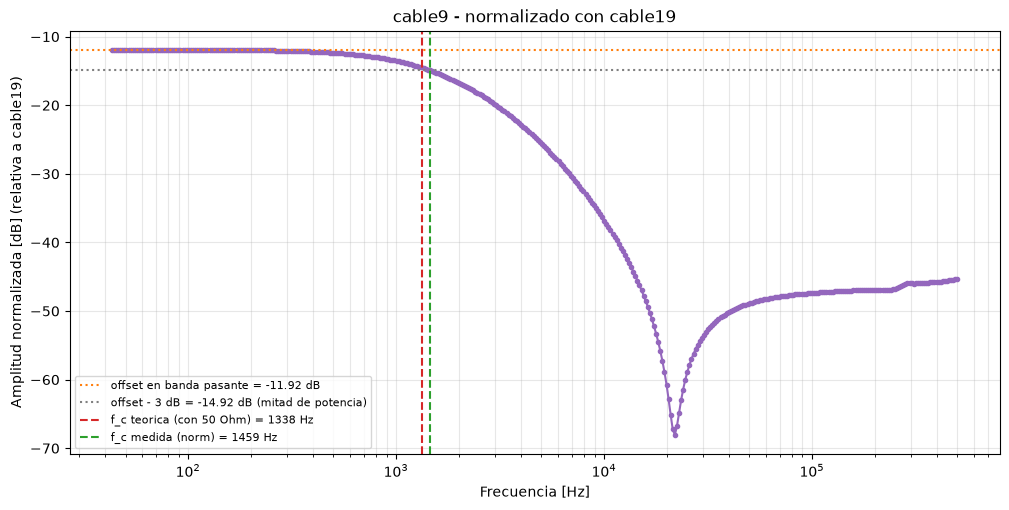

cable9 (normalizado con cable19): offset en banda pasante = 11.92 dB, f_c medida = 1458.8 Hz (teorica con 50 Ohm: 1338 Hz, diferencia: +9.1%)
offset teorico (divisor con 50 Ohm) = 12.04 dB

----------------------------------------------------------------------
cable3 normalizado con cable19
----------------------------------------------------------------------


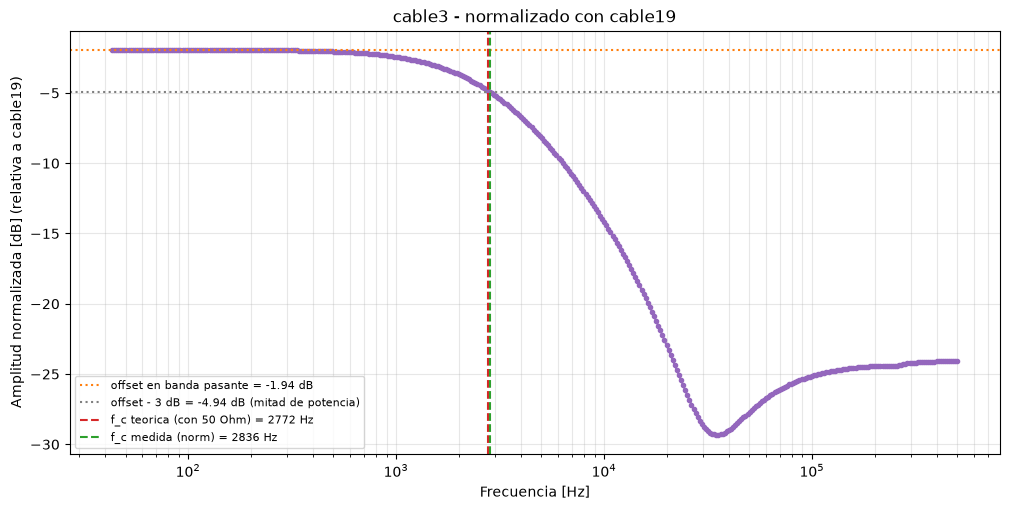

cable3 (normalizado con cable19): offset en banda pasante = 1.94 dB, f_c medida = 2836.4 Hz (teorica con 50 Ohm: 2772 Hz, diferencia: +2.3%)
offset teorico (divisor con 50 Ohm) = 2.28 dB

----------------------------------------------------------------------
cable13 normalizado con cable19
----------------------------------------------------------------------


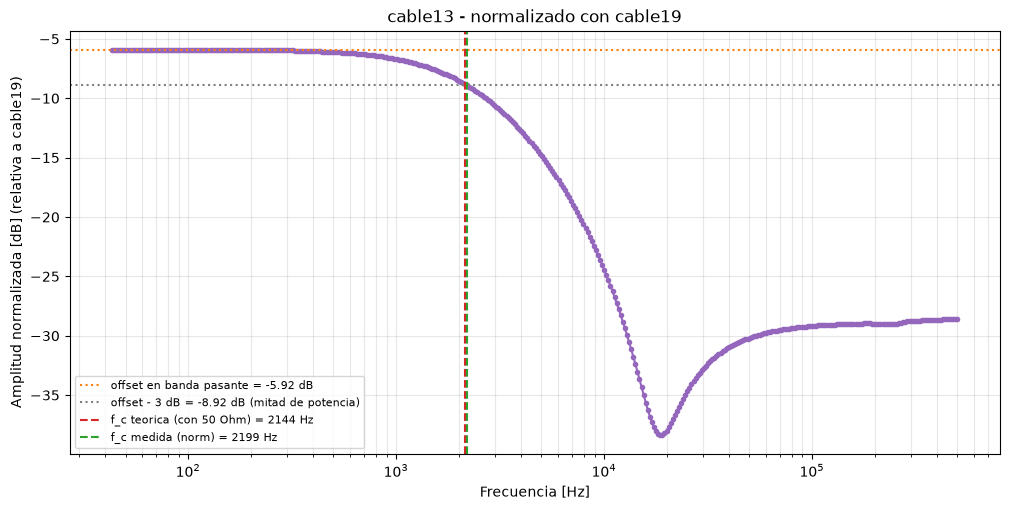

cable13 (normalizado con cable19): offset en banda pasante = 5.92 dB, f_c medida = 2199.4 Hz (teorica con 50 Ohm: 2144 Hz, diferencia: +2.6%)
offset teorico (divisor con 50 Ohm) = 6.11 dB

----------------------------------------------------------------------
cable18 normalizado con cable19
----------------------------------------------------------------------


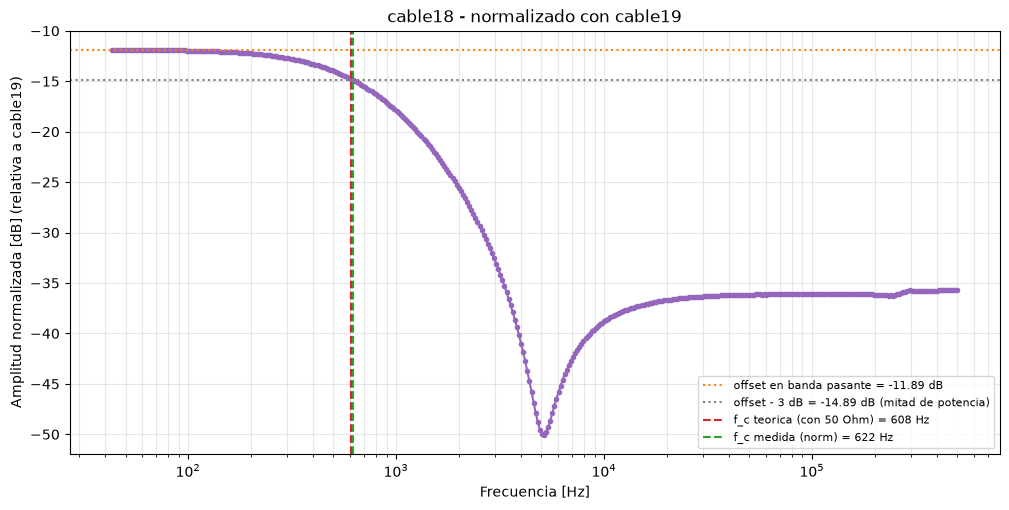

cable18 (normalizado con cable19): offset en banda pasante = 11.89 dB, f_c medida = 621.7 Hz (teorica con 50 Ohm: 608 Hz, diferencia: +2.2%)
offset teorico (divisor con 50 Ohm) = 12.04 dB

----------------------------------------------------------------------
cable14 normalizado con cable19
----------------------------------------------------------------------


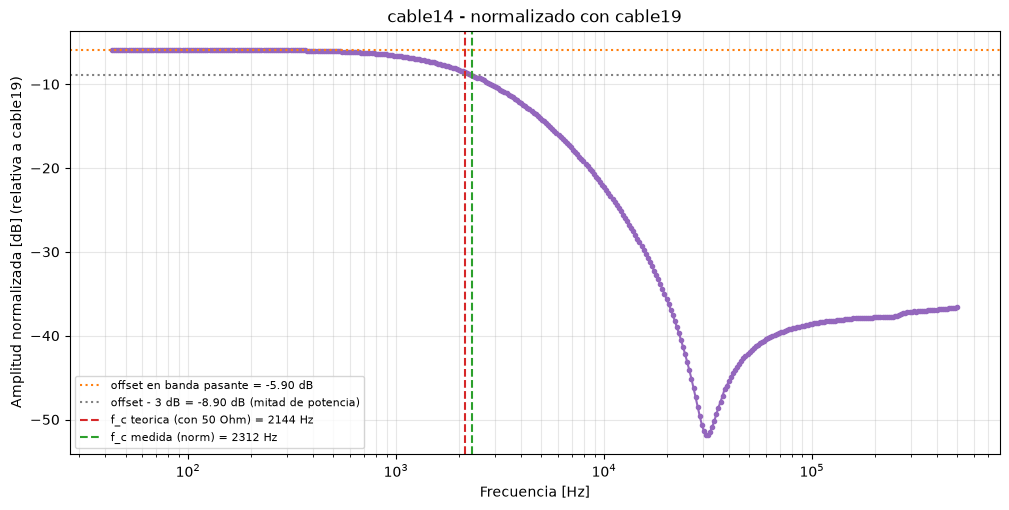

cable14 (normalizado con cable19): offset en banda pasante = 5.90 dB, f_c medida = 2311.8 Hz (teorica con 50 Ohm: 2144 Hz, diferencia: +7.8%)
offset teorico (divisor con 50 Ohm) = 6.11 dB


In [108]:
resumen_norm = []

for nombre, cfg in canales.items():
    # atenuacion en continua esperada por el divisor con los 50 Ohm (mismo signo que el offset medido)
    offset_teorico_db = 20 * np.log10((R_GEN + R_SA + 2 * cfg["R"]) / (R_GEN + R_SA))
    for nombre_cal, cal in calibraciones.items():
        print(f"\n{'-' * 70}\n{nombre} normalizado con {nombre_cal}\n{'-' * 70}")
        metrica_norm = analizar_canal_normalizado(nombre, cfg["carpeta"], cfg["f_c_teorica_hz"], cal, nombre_cal)
        print(f"offset teorico (divisor con 50 Ohm) = {offset_teorico_db:.2f} dB")
        resumen_norm.append(metrica_norm)

## Comparacion medicion vs. modelo

1. Todos los canales normalizados con `cable19` (puntos) junto con la
   respuesta simulada con 50 Ohm (linea), para ver si coincide la forma de
   toda la curva y no solo el punto de -3 dB.
2. f_c medida vs. teorica (con y sin carga) y offset medido vs. teorico.

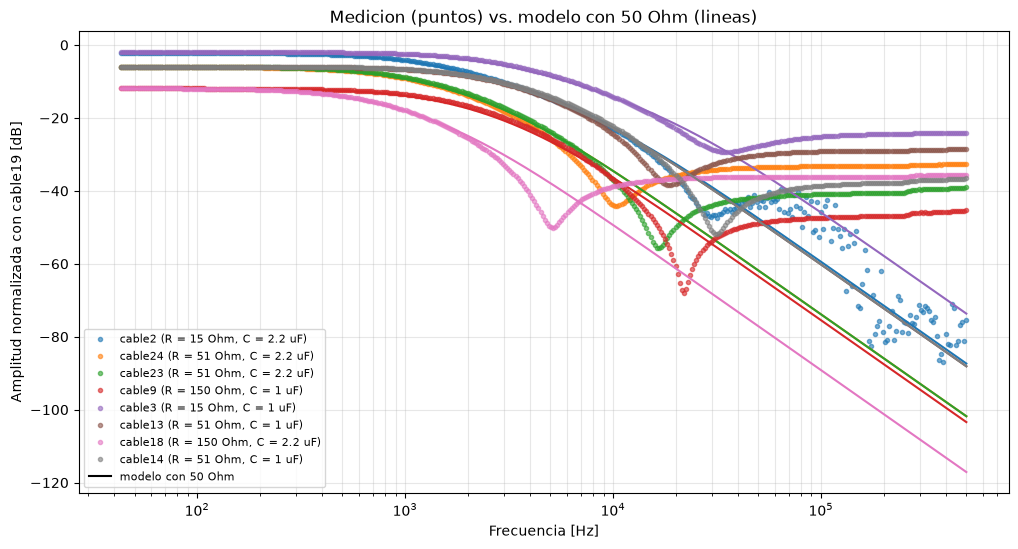

In [109]:
cal = calibraciones["cable19"]
loopback = R_SA / (R_GEN + R_SA)

plt.figure(figsize=(12, 6))
for nombre, cfg in canales.items():
    res = resultados_por_canal[nombre]
    amp_cal = np.interp(np.log10(res["f_test"]), np.log10(cal["f_test"]), cal["peak_amp"])
    norm_db = res["peak_amp"] - amp_cal

    f_modelo = np.logspace(np.log10(res["f_test"].min()), np.log10(res["f_test"].max()), 500)
    modelo_db = 20 * np.log10(abs(transferencia(f_modelo, cfg["R"], cfg["C"], R_GEN, R_SA)) / loopback)

    linea, = plt.plot(f_modelo, modelo_db, "-", lw=1.5)
    plt.plot(res["f_test"], norm_db, "o", ms=3, alpha=0.6, color=linea.get_color(),
             label=f"{nombre} (R = {cfg['R']} Ohm, C = {cfg['C'] * 1e6:g} uF)")

plt.plot([], [], "k-", label="modelo con 50 Ohm")
plt.xscale("log")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud normalizada con cable19 [dB]")
plt.title("Medicion (puntos) vs. modelo con 50 Ohm (lineas)")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8)
plt.show()

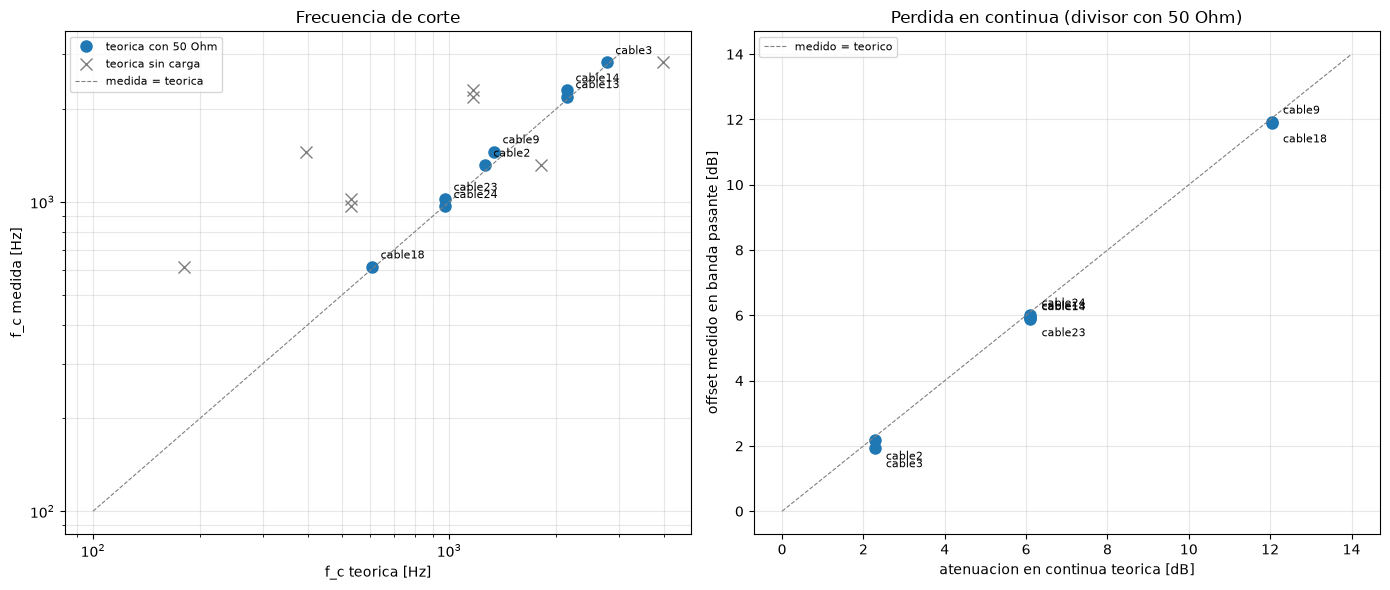

In [110]:
nombres = list(canales)
fc_medida = [m["f_c_medida_hz"] for m in resumen]
fc_con_carga = [canales[n]["f_c_teorica_hz"] for n in nombres]
fc_sin_carga = [fc_teorica(canales[n]["R"], canales[n]["C"]) for n in nombres]
offset_medido = [m["offset_banda_pasante_db"] for m in resumen_norm]
offset_teorico = [20 * np.log10((R_GEN + R_SA + 2 * canales[n]["R"]) / (R_GEN + R_SA)) for n in nombres]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

ax = axs[0]
ax.plot(fc_con_carga, fc_medida, "o", ms=8, label="teorica con 50 Ohm")
ax.plot(fc_sin_carga, fc_medida, "x", ms=8, color="tab:gray", label="teorica sin carga")
for n, x, y in zip(nombres, fc_con_carga, fc_medida):
    ax.annotate(n, (x, y), fontsize=8, xytext=(6, 6), textcoords="offset points")
lims = [100, 3000]
ax.plot(lims, lims, "--", color="gray", lw=0.8, label="medida = teorica")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("f_c teorica [Hz]")
ax.set_ylabel("f_c medida [Hz]")
ax.set_title("Frecuencia de corte")

ax = axs[1]
ax.plot(offset_teorico, offset_medido, "o", ms=8)
for i, (n, x, y) in enumerate(zip(nombres, offset_teorico, offset_medido)):
    # alterno arriba/abajo para que no se pisen los que tienen el mismo R
    ax.annotate(n, (x, y), fontsize=8, xytext=(8, 6 if i % 2 else -14), textcoords="offset points")
ax.plot([0, 14], [0, 14], "--", color="gray", lw=0.8, label="medido = teorico")
ax.set_xlabel("atenuacion en continua teorica [dB]")
ax.set_ylabel("offset medido en banda pasante [dB]")
ax.set_title("Perdida en continua (divisor con 50 Ohm)")

for ax in axs:
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()